<a href="https://colab.research.google.com/github/kailash11-hub/Customer-Segmentation-System/blob/main/Untitled1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install xgboost

In [2]:

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    silhouette_score
)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!find /content/drive/MyDrive -name "archive.zip"

/content/drive/MyDrive/archive.zip


In [5]:
import zipfile
zip_path = "/content/drive/MyDrive/archive.zip"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content")

print("Extracted successfully!")

Extracted successfully!


In [8]:
df = pd.read_csv("/content/Country-data.csv")
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [10]:
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [11]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


(167, 10)
Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')


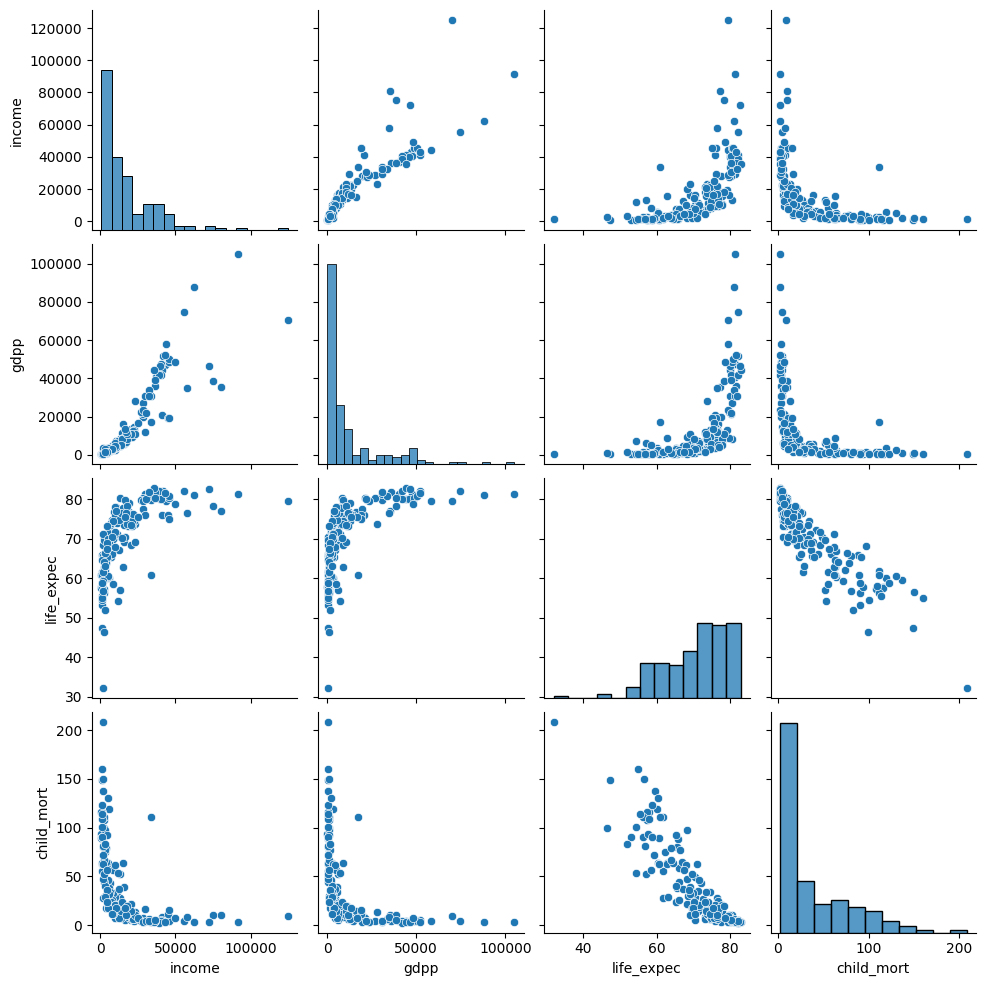

In [12]:
print(df.shape)
print(df.columns)

sns.pairplot(df[['income','gdpp','life_expec','child_mort']])
plt.show()

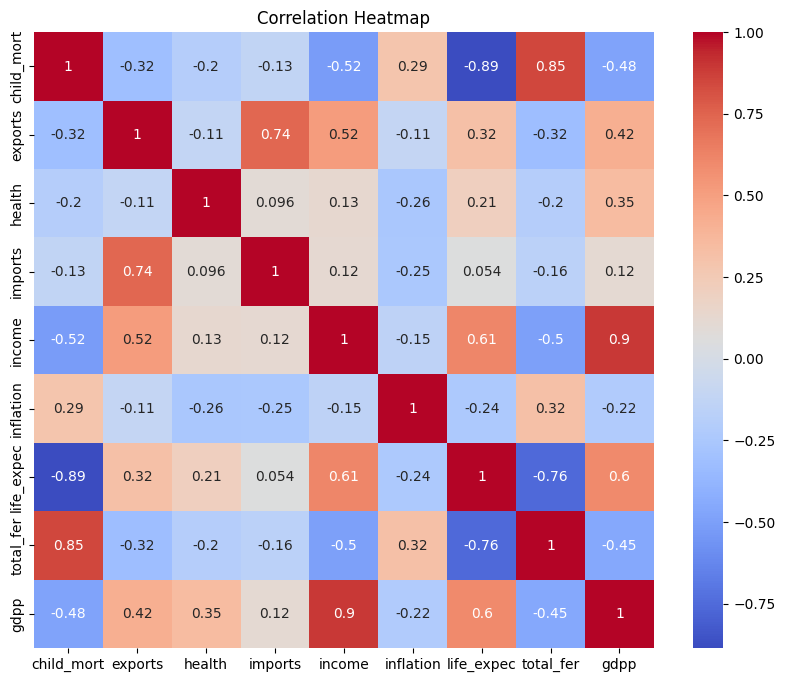

In [13]:
plt.figure(figsize=(10,8))
sns.heatmap(df.drop('country', axis=1).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

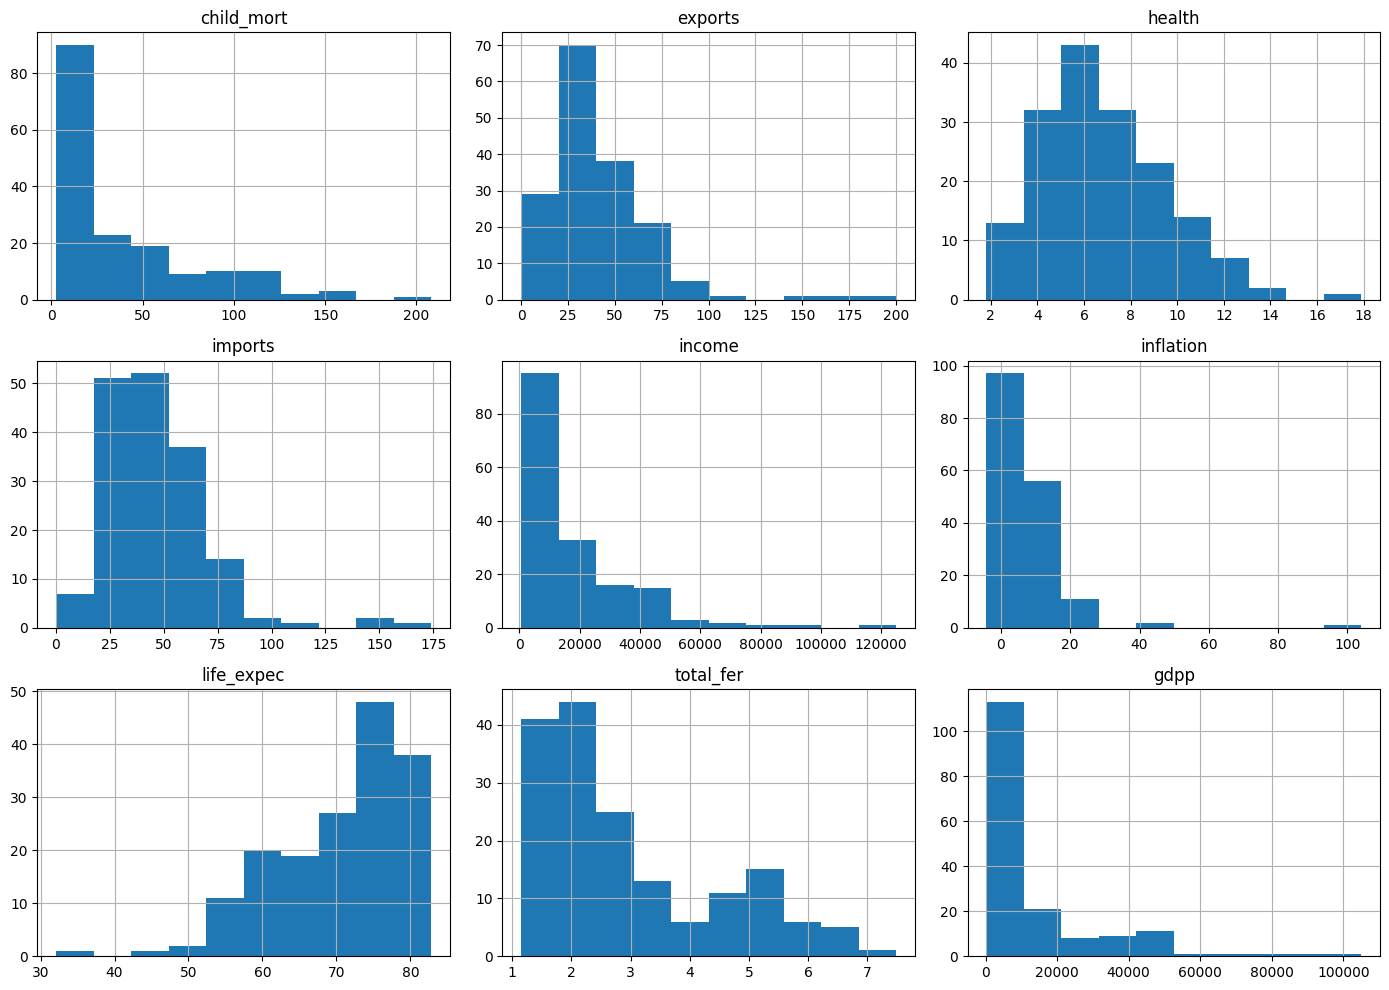

In [14]:
df.drop('country', axis=1).hist(figsize=(14,10))
plt.tight_layout()
plt.show()

In [15]:
from sklearn.preprocessing import StandardScaler

X = df.drop('country', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaled Data Shape:", X_scaled.shape)

Scaled Data Shape: (167, 9)


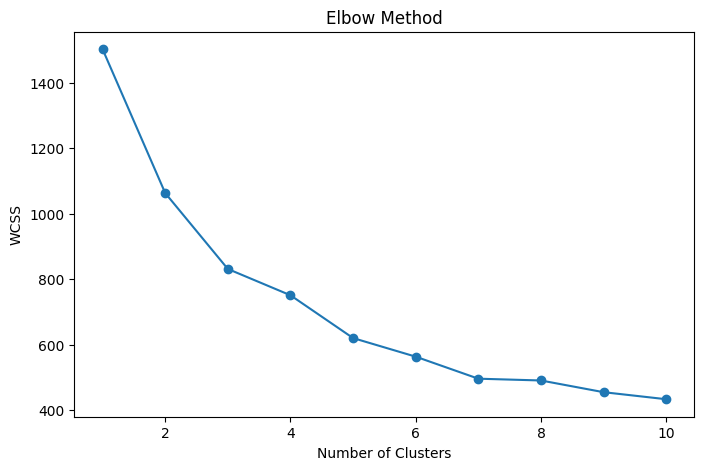

In [16]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [17]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df['Cluster'] = clusters
df.head()
print(df['Cluster'].value_counts())
score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", score)

Cluster
0    86
2    45
1    36
Name: count, dtype: int64
Silhouette Score: 0.285600988953231


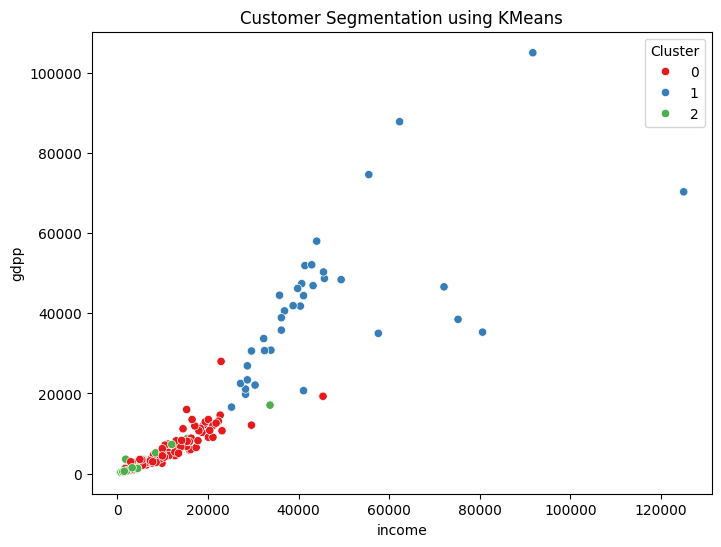

In [19]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='income',
    y='gdpp',
    hue='Cluster',
    data=df,
    palette='Set1'
)
plt.title("Customer Segmentation using KMeans")
plt.show()

In [20]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=5)

db_clusters = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = db_clusters
print(df["DBSCAN_Cluster"].value_counts())

valid = db_clusters != -1

if len(set(db_clusters[valid])) > 1:
    score = silhouette_score(X_scaled[valid], db_clusters[valid])
    print("DBSCAN Silhouette Score:", score)
df.head()

DBSCAN_Cluster
 0    137
-1     30
Name: count, dtype: int64


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster,DBSCAN_Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2,0
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2,-1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0,0


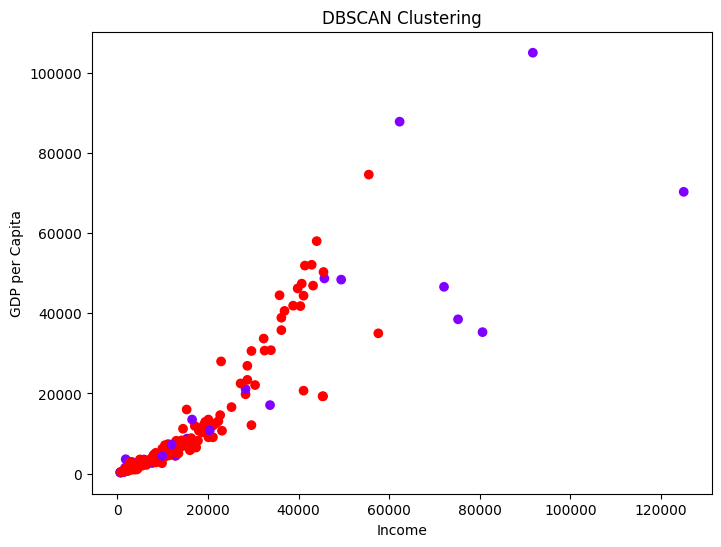

In [21]:
plt.figure(figsize=(8,6))
plt.scatter(df["income"], df["gdpp"], c=df["DBSCAN_Cluster"], cmap="rainbow")
plt.xlabel("Income")
plt.ylabel("GDP per Capita")
plt.title("DBSCAN Clustering")
plt.show()

In [29]:

X = df.drop(["country","Cluster","DBSCAN_Cluster"], axis=1)
y = df["Cluster"]
print(X.head())
print(y.value_counts())

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42)

   child_mort  exports  health  imports  income  inflation  life_expec  \
0        90.2     10.0    7.58     44.9    1610       9.44        56.2   
1        16.6     28.0    6.55     48.6    9930       4.49        76.3   
2        27.3     38.4    4.17     31.4   12900      16.10        76.5   
3       119.0     62.3    2.85     42.9    5900      22.40        60.1   
4        10.3     45.5    6.03     58.9   19100       1.44        76.8   

   total_fer   gdpp  
0       5.82    553  
1       1.65   4090  
2       2.89   4460  
3       6.16   3530  
4       2.13  12200  
Cluster
0    86
2    45
1    36
Name: count, dtype: int64


In [24]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(random_state=42)
rf.fit(X_train,y_train)
pred=rf.predict(X_test)

In [30]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score

baseline = DummyClassifier(strategy="most_frequent", random_state=42)
baseline.fit(X_train, y_train)
baseline_acc = baseline.score(X_test, y_test)
print("Baseline (majority class) accuracy:", baseline_acc)

rf_cv_scores = cross_val_score(rf, X, y, cv=5)
print("Random Forest CV accuracy: %.4f +/- %.4f" % (rf_cv_scores.mean(), rf_cv_scores.std()))


Baseline (majority class) accuracy: 0.5882352941176471
Random Forest CV accuracy: 0.9638 +/- 0.0446


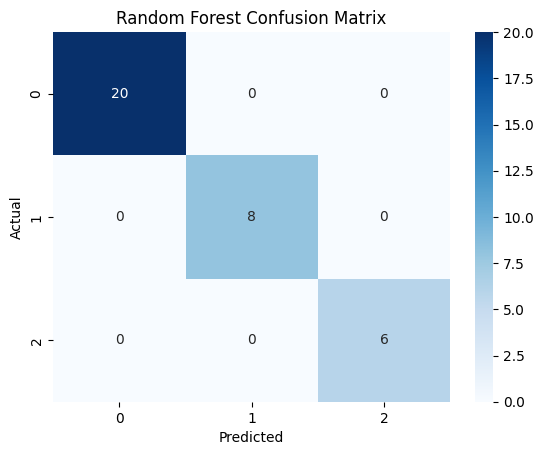

Accuracy : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         6

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



In [31]:
cm = confusion_matrix(y_test,pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()
print("Accuracy :",accuracy_score(y_test,pred))
print(classification_report(y_test,pred))

Random Forest Accuracy: 1.0
XGBoost Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         6

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



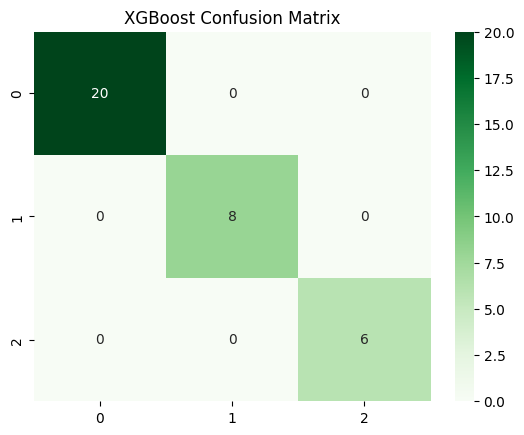

XGBoost CV accuracy: 0.9699 +/- 0.0192


In [32]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(X_train,y_train)

pred2 = xgb.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, pred))
print("XGBoost Accuracy:", accuracy_score(y_test, pred2))
print(classification_report(y_test,pred2))
cm = confusion_matrix(y_test,pred2)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("XGBoost Confusion Matrix")

plt.show()
xgb_cv_scores = cross_val_score(xgb, X, y, cv=5)
print("XGBoost CV accuracy: %.4f +/- %.4f" % (xgb_cv_scores.mean(), xgb_cv_scores.std()))


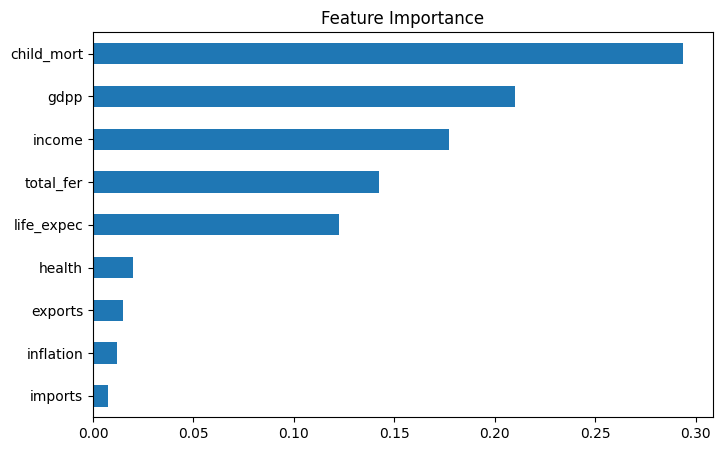

In [33]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title("Feature Importance")
plt.show()

In [34]:
results = pd.DataFrame({
    'Model': ['Baseline (majority class)', 'Random Forest', 'Random Forest (5-fold CV)',
              'XGBoost', 'XGBoost (5-fold CV)'],
    'Accuracy': [baseline_acc,
                 accuracy_score(y_test, pred),
                 rf_cv_scores.mean(),
                 accuracy_score(y_test, pred2),
                 xgb_cv_scores.mean()]
})
print(results)


                       Model  Accuracy
0  Baseline (majority class)  0.588235
1              Random Forest  1.000000
2  Random Forest (5-fold CV)  0.963815
3                    XGBoost  1.000000
4        XGBoost (5-fold CV)  0.969875
